# Bayesian optimisation of eight black-box functions

This notebook fits a fully Bayesian Gaussian process surrogate to one black-box
function, diagnoses the fit, compares the point that each acquisition function
would query next, and saves the result.

**Run the cells in order.** Everything you would normally want to change lives in
section 2; the rest of the notebook reads from it, so no value is written twice.

### Setting up the environment for use with Jupyter

Open an anaconda prompt terminal in the root of the repository:

```bash
conda create -n bbo python=3.11
conda activate bbo
python -m pip install --upgrade pip
pip install -r requirements.txt

```

Then register the kernel and select **Python 3.11 (BBO)** when you open this
notebook:

```bash
pip install jupyter ipykernel
python -m ipykernel install --user --name bbo --display-name "Python 3.11 (BBO)"
jupyter lab
```

In [ ]:
### Setting up the environment for use with Google Colab

# import os, sys

# IN_COLAB = "google.colab" in sys.modules

# if IN_COLAB:
#     !git clone -q https://github.com/loukiakri/bbo.git
#     %cd bbo
#     !pip install -q -r requirements-colab.txt
#     print("Installed. If prompted, Runtime > Restart session, then re-run from here.")

# if not IN_COLAB:
#     %matplotlib widget
# else:
#     %matplotlib inline

## 1. Imports and paths


In [4]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd() / "src"))

import torch
from bo_plot import (plot_bo_slice, slice_predict_from_botorch, plot_parallel_coords,
                     plot_lengthscales, plot_bayesian_optimization,
                     plot_pca_scatter, plot_pca_scree)
from check_fit import check_fit
from bo_utils import load_function_data, get_lengthscales, lengthscale_stats, pca_loadings
from bo_model import fit_and_suggest
from compare_candidates import compare_candidates

# %matplotlib widget   # turn on if interactive plots are needed
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.double)   # GPs need float64

# Path to the data folder, relative to the notebook. Leave as-is if the
# repository was downloaded from GitHub.
DATA_PATH = Path.cwd() / "data"

## 2. Configuration

Every lever is in the cell below, grouped by what it controls. Nothing further
down hard-codes a function number, a dimension or a model setting.

| group | lever | what it does | when to change it |
|---|---|---|---|
| data | `FUNCTION` | which black-box function, 1–8 | every run |
| | `QUERY_ROUND` | how much history to load: `None` = all rounds, `k` = the state before round *k+1*, `0` = initial design only | to reproduce an earlier round |
| model | `model_type` | `single_task`, `single_task_tight`, `saas`, `saas_tight` | `saas*` for high dimension; `*_tight` to constrain the priors below |
| | `warmup`, `num_samples`, `thinning` | NUTS chain length and retention | raise if lengthscales look under-mixed |
| | `seed` | reproducibility | fix for a submission |
| priors | `ls_loc`, `ls_scale` | log-space lengthscale prior (`single_task_tight` only) | when lengthscales run away |
| | `noise_floor`, `noise_prior_scale` | noise level and spread (`*_tight` only) | when the fit interpolates |
| | `ls_alpha` | global shrinkage scale (`saas_tight` only) | to tune SAAS sparsity |
| acquisition | `acquisition` | `ei`, `ucb`, `pi`, `thompson` | per round |
| | `ucb_beta` | exploration weight, UCB only | raise to explore |
| | `mc_samples` | MC samples per acquisition evaluation | lower to 32–64 on memory pressure |
| search | `min_dist`, `exclusion_weight`, `exclude_X` | keep the next point away from existing observations | when candidates collapse onto the incumbent |
| | `search_bounds` | trust region for the next point; `bounds` still governs the diagnostic grid | to confine the search |
| compute | `cv`, `n_splits` | `loo` or `kfold` calibration | `kfold` for speed on large n |
| | `posterior_batch_size` | posterior chunk size | lower on memory pressure |
| | `upper_eps` | acquisition optimiser tolerance | rarely |
| save | `SAVE_ROUND` | round number written into the filename; `None` infers it | rarely |

Full argument documentation is in the docstrings of `check_fit`, `fit_and_suggest`
and `compare_candidates`.

In [18]:
# ---- what to load -------------------------------------------------------
FUNCTION    = 6
QUERY_ROUND = 12        # None = every round on file; k = state before round k+1

# ---- model --------------------------------------------------------------
MODEL = dict(model_type="single_task_tight", seed=0,
             warmup=128, num_samples=128, thinning=8)

# ---- priors (only used by the *_tight model types) ----------------------
PRIORS = dict(ls_loc=0.1, ls_scale=1.0, noise_floor=0.008)
# PRIORS = dict()                    # plain single_task / saas: no prior overrides
# PRIORS = dict(ls_alpha=0.1)        # saas_tight

# ---- acquisition --------------------------------------------------------
ACQ = dict(acquisition="ucb", ucb_beta=0.01, mc_samples=64)

# ---- restrictions on where the next point may go (all off by default) ---
SEARCH = dict(min_dist=0.0, exclusion_weight=1e4,
              exclude_X=None, search_bounds=None)

# ---- compute and diagnostics -------------------------------------------
COMPUTE = dict(cv="loo", upper_eps=1e-5, posterior_batch_size=64)

# ---- saving -------------------------------------------------------------
SAVE_ROUND = None         # None -> inferred as (queries loaded) + 1
SAVE_DIR   = Path.cwd()

# Single source of truth for both check_fit and the candidate comparison.
FIT_KW = {**MODEL, **PRIORS, **ACQ, **SEARCH, **COMPUTE}

## 3. Load the data

`QUERY_ROUND` controls how much of the history is appended to the initial
design, so any earlier state can be reproduced exactly.

Note the off-by-one: round *r*'s saved file was fitted on the data available
*before* round *r* was evaluated, so `res_f6_query13.joblib` corresponds to
`QUERY_ROUND=12`.

`d`, the input dimension, and the axis labels are derived from the loaded data
rather than typed in, so they cannot fall out of step with `FUNCTION`.

In [21]:
fcn_inputs_up, fcn_outputs_up, fcn_inputs, fcn_outputs = load_function_data(
    function_number=FUNCTION, data_path=DATA_PATH, query_round=QUERY_ROUND)

d          = fcn_inputs_up.shape[1]                       # input dimension
dim_labels = [f"x{j + 1}" for j in range(d)]
n_initial  = len(fcn_outputs)
n_queries  = len(fcn_outputs_up) - n_initial

X      = torch.tensor(fcn_inputs_up, dtype=torch.double)
y      = torch.tensor(fcn_outputs_up, dtype=torch.double).reshape(-1, 1)
bounds = torch.stack([torch.zeros(d), torch.ones(d)])     # inputs are already in [0,1]^d

print(f"function F{FUNCTION}  |  {d}D  |  {n_initial} initial + {n_queries} queries "
      f"= {len(fcn_outputs_up)} observations")
print(f"best so far           : {float(np.max(fcn_outputs_up)):.6g}")
print(f"best of initial design: {float(np.max(fcn_outputs)):.6g}")

function F6  |  5D  |  20 initial + 12 queries = 32 observations
best so far           : -0.12742
best of initial design: -0.714265


## 4. Optimisation progress so far

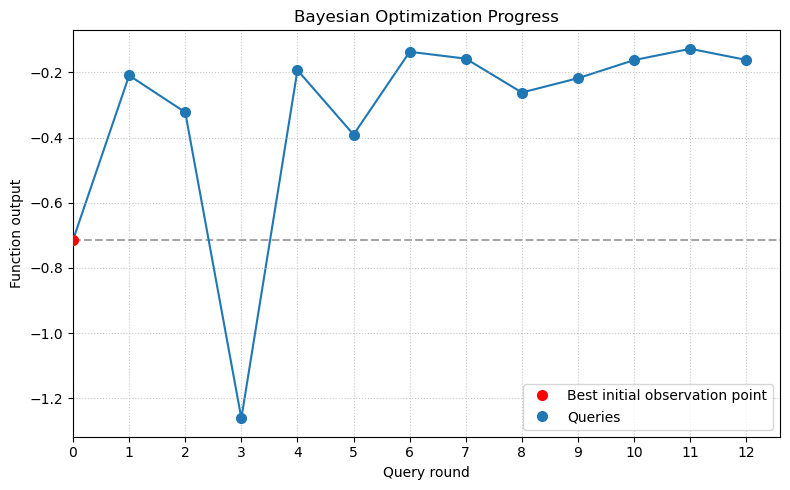

In [24]:
plot_bayesian_optimization(fcn_outputs, fcn_outputs_up)

## 5. Fit the surrogate and check the calibration

`check_fit` fits the model, runs out-of-sample calibration and proposes the next
point. The settings are printed alongside so that any figure or saved file taken
from this run is self-documenting.

Read the calibration line as: **z-std** near 1 is well calibrated, above ~1.3
overconfident, below ~0.7 underconfident; **coverage95** should sit near 95%.

In [27]:
for k, v in FIT_KW.items():
    print(f"  {k:22s} = {v}")

res = check_fit(X, y, bounds, **FIT_KW)
out = res["out"]

  model_type             = single_task_tight
  seed                   = 0
  warmup                 = 128
  num_samples            = 128
  thinning               = 8
  ls_loc                 = 0.1
  ls_scale               = 1.0
  noise_floor            = 0.008
  acquisition            = ucb
  ucb_beta               = 0.01
  mc_samples             = 64
  min_dist               = 0.0
  exclusion_weight       = 10000.0
  exclude_X              = None
  search_bounds          = None
  cv                     = loo
  upper_eps              = 1e-05
  posterior_batch_size   = 64
  --- calibration: LOO (32 refits) ---
    RMSE        : 0.2352
    z mean/std  : -0.150 / 1.026  (target ~0 / ~1)
    95% coverage: 97%  (target ~95%)
    NLPD        : -0.3537  (lower is better)
    -> calibration looks reasonable.
  n=32, y-span=2.44, y-std=0.714, acq=ucb
  out-of-sample RMSE : 0.2352  (10% of span)  [LOO (32 refits)]
  skill vs mean      : 0.67  (1=perfect, 0=no better than predicting the mean)
    

### 5b. Optional: compare against a second model type

Everything downstream uses `res`, so if you run the cell below, decide
explicitly which fit you are carrying forward. Leaving `res` pointing at the
section 5 fit is the safe default.

In [30]:
# res_alt = check_fit(X, y, bounds, **{**FIT_KW, "model_type": "single_task",
#                                      "ls_loc": None, "ls_scale": None,
#                                      "noise_floor": None})
#
# To carry the alternative forward instead, uncomment BOTH lines:
# res = res_alt
# out = res["out"]

## 6. Lengthscale diagnostics

Short lengthscale = the model thinks that dimension matters. Wide spread across
NUTS samples = the chain has not settled on a view of that dimension.

  --- Lengthscale stats (16 samples) ---
    dim       geo_mean  x/÷ factor
    x1          0.8371       1.422
    x2          0.8111        1.35
    x3           1.109       1.501
    x4          0.9055       1.497
    x5          0.9463       1.574


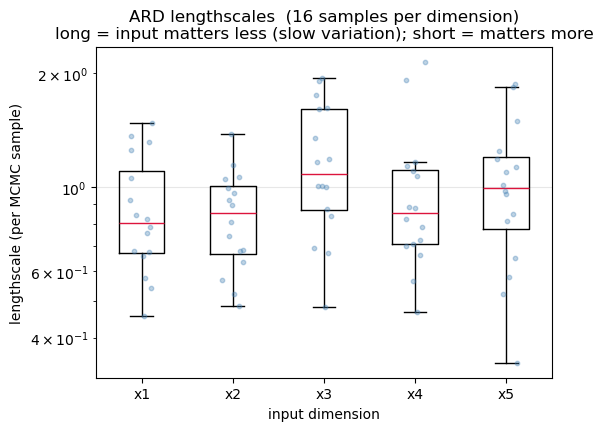

In [33]:
ls    = get_lengthscales(out) 
stats = lengthscale_stats(ls, dim_labels=dim_labels)
fig_ls = plot_lengthscales(ls)

## 7. Where the next point sits

Parallel coordinates show every dimension at once; the slice plot re-evaluates
the GP on a 2-D cut through the best point.

next_x: [0.390069 0.353407 0.691056 0.742125 0.111512]


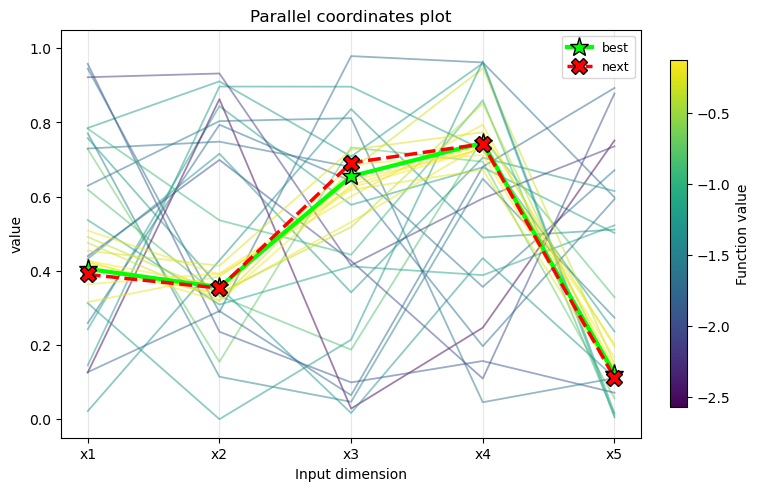

In [36]:
fig_pc = plot_parallel_coords(X, y, res["next_x"], bounds=bounds)
print("next_x:", np.round(res["next_x"], 6))

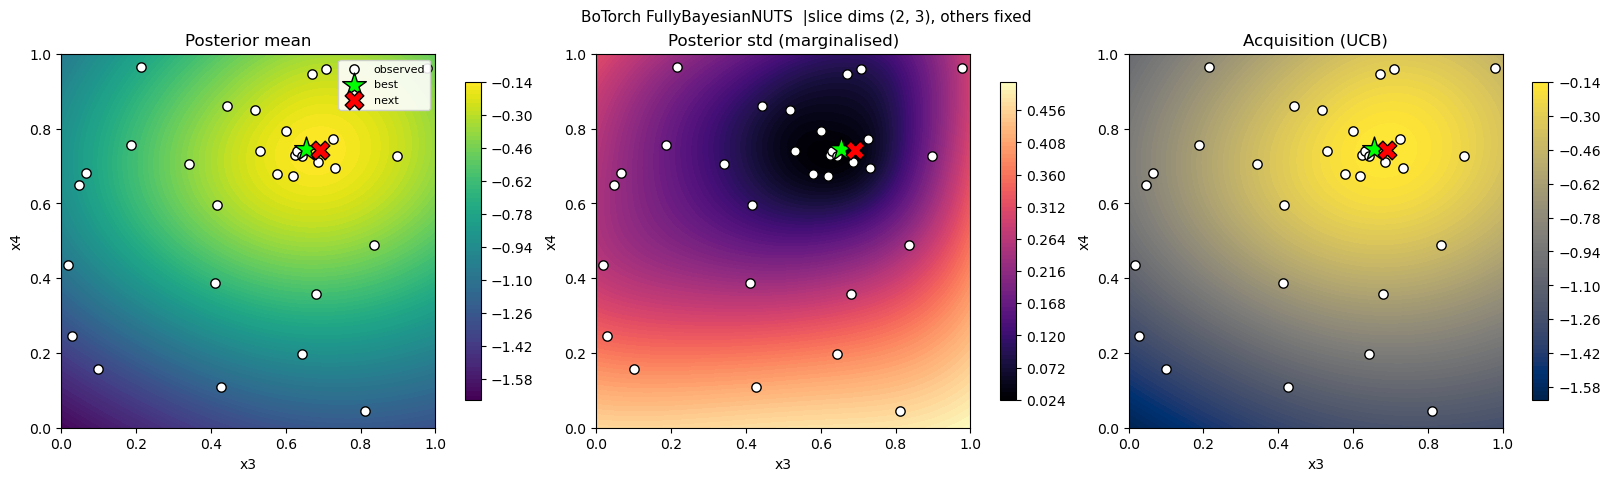

In [38]:
# Choose which two dimensions to show; the rest stay fixed at the best point.
SLICE_DIMS = (0, 1) if d < 4 else (2, 3)

reeval = slice_predict_from_botorch(out, batch_size=64)
sl = plot_bo_slice(out, X, y, bounds, dims=SLICE_DIMS, fixed="best", reevaluate=reeval)

fig = plt.gcf()
# Force the interactive canvas width (only when %matplotlib widget is on)
# fig.canvas.layout.width = "1600px"
# fig.canvas.layout.min_width = "1200px"
plt.show()

## 8. Candidate comparison

Each acquisition function is fitted separately and its proposal is cross-scored
under all the others. The settings are taken from `FIT_KW`, so this comparison
**cannot** drift from the fit in section 5 — that was the easiest mistake to make
in the previous layout.

`run_loo=False` because the calibration has already been computed once.

In [41]:
# Same settings as section 5, minus the acquisition (passed per call).
kw = {k: v for k, v in FIT_KW.items() if k != "acquisition"}
kw["run_loo"] = False

out_ei  = fit_and_suggest(X, y, bounds, acquisition="ei",       **kw)
out_pi  = fit_and_suggest(X, y, bounds, acquisition="pi",       **kw)
out_ucb = fit_and_suggest(X, y, bounds, acquisition="ucb",      **kw)
out_ts  = fit_and_suggest(X, y, bounds, acquisition="thompson", **kw)

report = compare_candidates(out_ei, out_ucb, out_pi, out_ts, X, y, bounds,
                            posterior_batch_size=FIT_KW["posterior_batch_size"])

CANDIDATE POINTS
  ei        : [0.3937 0.3483 0.8478 0.7359 0.    ]
  ucb       : [0.3901 0.3534 0.6911 0.7421 0.1115]
  pi        : [0.3962 0.3547 0.713  0.7389 0.0623]
  thompson  : [0.    0.092 1.    0.    0.   ]

CROSS-EVALUATION (~0-1 scale per scorer;
 1.0 = as good as that acquisition function's own optimum on the grid)
  scored by \ candidate            ei         ucb          pi    thompson
  ei                            1.00        0.97        0.99        0.90
  ucb                           0.96        1.00        1.00        0.47
  pi                            0.79        0.88        1.00        0.01
  thompson                      0.87        0.88        0.87        1.00

  Read by ROW

LENGTHSCALE-NORMALISED DISTANCE BETWEEN CANDIDATES
  (in units of the model's own median ARD lengthscale per dim --
   >~1 means the gap exceeds a lengthscale e.g
   the model would treat these as meaningfully separated)
  ei         <-> ucb       : 0.183
  ei         <-> pi        : 0.13

## 9. PCA views of the design

Two projections. The **unweighted** view answers "which combined direction have I
explored most". The **lengthscale-weighted** view divides each input by that
dimension's lengthscale first, so it answers "which combined direction matters
most to the model".

PCA LOADINGS (which input dimension makes up each principal component)
  loading = d(PC score)/d(x_j), in raw [0,1] input units
  (sign: + means increasing that input increases the PC score)

  PC1 (37.6% variance):
    x5      : +0.649  #############
    x4      : -0.526  ###########
    x2      : +0.492  ##########
    x1      : -0.195  ####
    x3      : -0.147  ###

  PC2 (24.9% variance):
    x3      : +0.836  #################
    x2      : +0.429  #########
    x1      : -0.272  #####
    x4      : +0.202  ####
    x5      : -0.054  #

  PC3 (17.9% variance):
    x1      : +0.864  #################
    x2      : +0.330  #######
    x4      : -0.287  ######
    x5      : -0.186  ####
    x3      : +0.169  ###

  PC4 (11.2% variance):
    x4      : +0.712  ##############
    x5      : +0.601  ############
    x1      : +0.346  #######
    x2      : +0.086  ##
    x3      : -0.065  #

  PC5 (8.4% variance):
    x2      : +0.676  ##############
    x3      : -0.497  ##########
    x

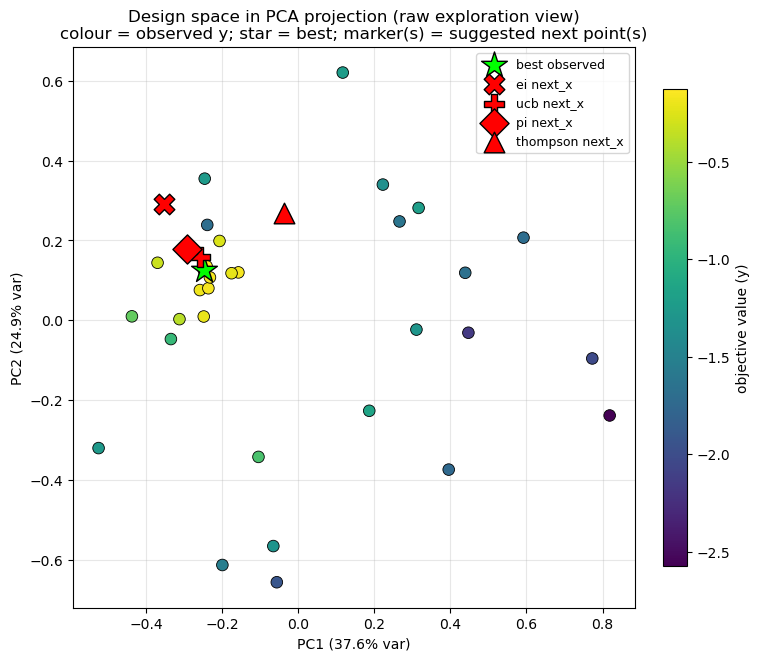

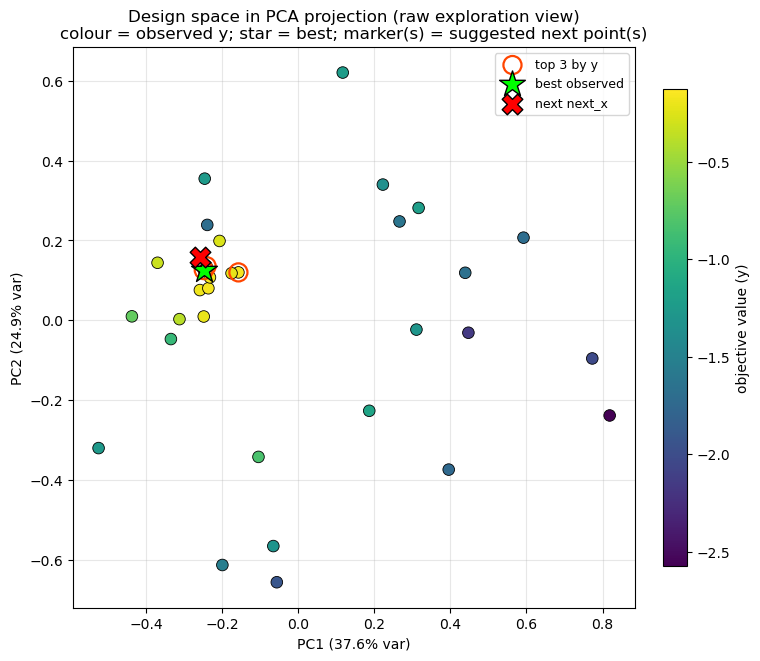

In [44]:
# Unweighted
loadings = pca_loadings(X, dim_labels=dim_labels)

fig_a = plot_pca_scatter(X, y, candidates=report["candidates"])   # one marker per acquisition
fig_b = plot_pca_scatter(X, y, candidates=out["next_x"], highlight_top=0.1)

# plot_pca_scree(X)   # % variance per component, cumulative line, 95% reference

PCA LOADINGS (which input dimension makes up each principal component)
  loading = d(PC score)/d(x_j), in lengthscale-normalised units (model-relevant view)
  (sign: + means increasing that input increases the PC score)

  PC1 (38.3% variance):
    x2      : +0.571  ###########
    x4      : -0.561  ###########
    x5      : +0.537  ###########
    x1      : -0.261  #####
    x3      : -0.052  #

  PC2 (23.5% variance):
    x1      : +0.844  #################
    x4      : -0.401  ########
    x3      : -0.352  #######
    x2      : -0.056  #
    x5      : +0.016  #

  PC3 (19.5% variance):
    x3      : +0.628  #############
    x2      : +0.611  ############
    x1      : +0.398  ########
    x5      : -0.194  ####
    x4      : +0.193  ####

  PC4 (11.2% variance):
    x4      : +0.673  #############
    x5      : +0.650  #############
    x3      : -0.257  #####
    x1      : +0.209  ####
    x2      : +0.120  ##

  PC5 (7.6% variance):
    x3      : +0.643  #############
    x2   

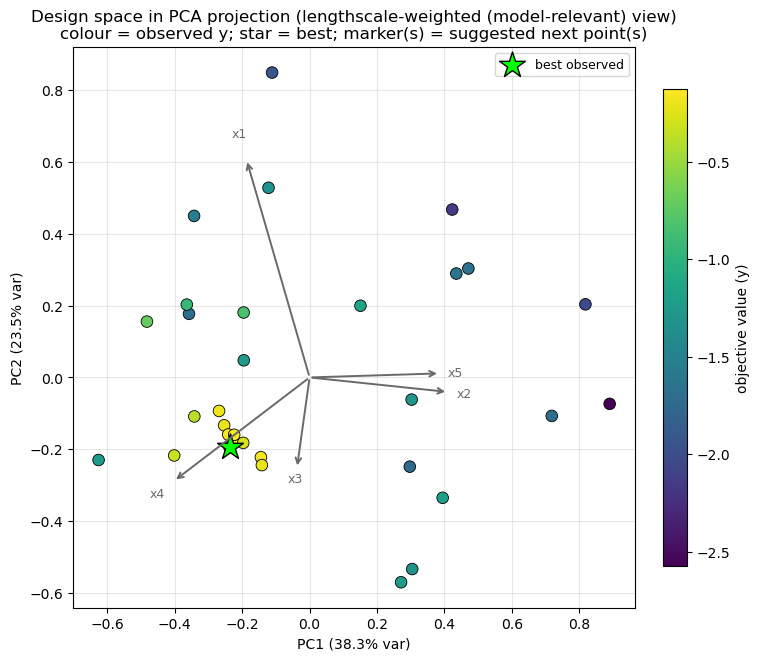

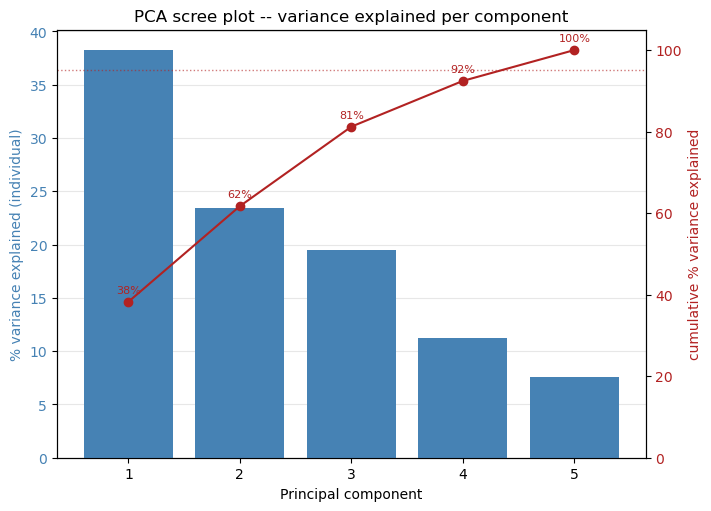

In [46]:
# Lengthscale-weighted
ls_median  = report["lengthscale_median"]

loadings_w = pca_loadings(X, dim_labels=dim_labels, lengthscales=ls_median)
fig_c = plot_pca_scatter(X, y, lengthscales=ls_median, show_loadings=True)
fig_d = plot_pca_scree(X, lengthscales=ls_median)

## 10. Save

The filename and the metadata are derived from the configuration, so there is no
round number or function label to keep in sync by hand.

In [ ]:
import joblib

round_label = SAVE_ROUND if SAVE_ROUND is not None else n_queries + 1

results_to_save = {
    "week": round_label,
    "function": f"F{FUNCTION}",
    "SelectedMethodOut": res,      # model output from check_fit
    "CompCand": report,            # candidate comparison report
    "ls": ls,                      # retained lengthscale samples
    "lsstats": stats,              # lengthscale summary
    "config": FIT_KW,              # the settings that produced all of the above
}

filename = SAVE_DIR / f"res_f{FUNCTION}_query{round_label}.joblib"
joblib.dump(results_to_save, filename)
print("saved:", filename)